# Complex Exponential Smoothing (CES)

This notebook demonstrates the **Complex Exponential Smoothing (CES)** forecaster in the `aeon` toolkit. CES is an exponential-smoothing method with an unusual twist: its smoothing parameter and its state are **complex numbers**. That single idea lets one model form reproduce flat, trending, and seasonal behaviour without you having to specify a separate trend or (for the non-seasonal model) any extra components.

CES was proposed by Svetunkov and Kourentzes (2018). It performed competitively in the M3/M4 competitions and is attractive because it sits outside the usual ETS taxonomy: there is no explicit "level + trend + season" decomposition to choose.

> Svetunkov, I., & Kourentzes, N. (2018). Complex exponential smoothing for time series forecasting. *Naval Research Logistics*, 65(8), 685-704. https://doi.org/10.1002/nav.21813

*If you have not seen the simpler members of the exponential-smoothing family, the [ETS notebook](../ets.ipynb) and the [Theta](theta.ipynb)/[DOTM](dotm.ipynb) notebooks are a gentler starting point.*


## 1. How the CES algorithm works

Ordinary simple exponential smoothing (SES) keeps a single real-valued level $\ell_t$ and updates it with one smoothing parameter $\alpha$. CES instead keeps a **two-component state** $(\ell_{1,t}, \ell_{2,t})$ — think of it as the real and imaginary parts of a complex level — and updates it with a **complex smoothing parameter** $\tilde{\alpha} = \alpha_0 + i\, \alpha_1$.

For the non-seasonal model (`model="N"`) the one-step forecast is just the real component,

$$\hat{y}_t = \ell_{1,t-1}, \qquad \varepsilon_t = y_t - \hat{y}_t,$$

and the two state components are updated together:

$$\ell_{1,t} = \ell_{1,t-1} + (\alpha_1 - 1)\,\ell_{2,t-1} + (\alpha_0 - \alpha_1)\,\varepsilon_t,$$
$$\ell_{2,t} = \ell_{1,t-1} + (1 - \alpha_0)\,\ell_{2,t-1} + (\alpha_0 + \alpha_1)\,\varepsilon_t.$$

The second component $\ell_{2}$ has no direct interpretation as a level or a trend — Svetunkov and Kourentzes call it the **information potential**. It is what gives CES its flexibility: because the two components feed back into each other through complex coefficients, the effective weight CES places on past observations is *not* a simple geometric decay (as in SES). It can be non-monotonic and long-memoried, which is how the same model can behave like a flat forecaster on stationary data and like a trended forecaster on a rising series — **without an explicit trend term**.

**Seasonal variants.** Three seasonal models add seasonal state lagged by `season_length`:

- `model="S"` (simple seasonal): the two-component CES state is itself updated at the seasonal lag.
- `model="P"` (partial seasonal): the non-seasonal complex state plus a single additive seasonal component (smoothing $\beta_0$).
- `model="F"` (full seasonal): adds a *second* complex state pair for the season with its own complex smoothing $\tilde{\beta} = \beta_0 + i\,\beta_1$.

`AutoCES` fits all four and picks the best by information criterion.


## 2. Parameters and their effects

- **`model`** (default `"N"`): which variant to fit — `"N"` (non-seasonal), `"S"`, `"P"`, `"F"` (seasonal). Long aliases `"none"`, `"simple"`, `"partial"`, `"full"` are also accepted.
- **`season_length`** (default `1`): seasonal period; must be `>= 2` for any seasonal model (e.g. `12` for monthly data).
- **`alpha_real`, `alpha_imag`** (default `None` -> estimated): the real and imaginary parts of the complex smoothing parameter $\tilde{\alpha}$. Together they determine the dynamics (see the worked example). Fix them to pin the model down; leave them `None` to estimate by maximum likelihood.
- **`beta_real`, `beta_imag`** (default `None` -> estimated): seasonal smoothing components. `beta_real` is used by `"P"` and `"F"`; `beta_imag` only by `"F"`.
- **`initial_level`, `initial_level_imag`**: seeds for the two state components. Seeded deterministically from the data if `None`.
- **bounds** (`alpha_real_bounds=(0.01, 1.8)`, `alpha_imag_bounds=(0.01, 1.9)`, etc.): box constraints for the optimiser. These match StatsForecast's AutoCES bounds and are *practical optimisation bounds, not the full CES admissibility region*.

Unlike Holt or ETS you do not choose a trend or damping type — the complex $\tilde{\alpha}$ absorbs that choice. The main decision is simply whether the data is seasonal, and if so which seasonal variant (or let `AutoCES` decide).


## 3. Forecasting with CES

### Imports


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from aeon.datasets import load_airline
from aeon.forecasting.stats import CES, AutoCES

### Example: fit, `forecast` and `iterative_forecast`

`forecast` returns the one-step-ahead value; `iterative_forecast` rolls the model forward over a horizon. We use a trending series and hold out the last 12 points as a test set. Note we never tell CES there is a trend — the non-seasonal model picks it up on its own.


One-step-ahead forecast: 34.019


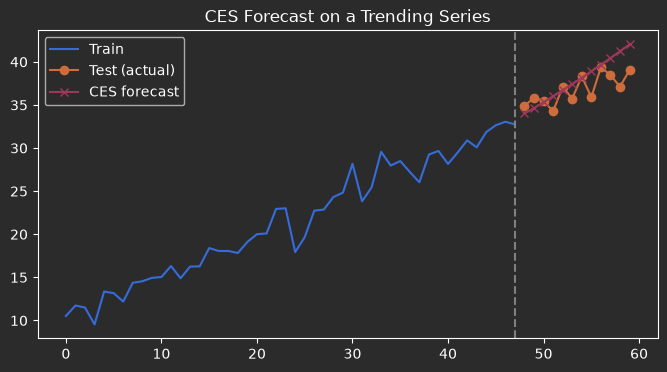

Test MSE over 12 steps: 3.914


In [2]:
# A trending series + noise
rng = np.random.default_rng(1)
n_points = 60
time = np.arange(n_points)
y = 10 + 0.5 * time + rng.normal(scale=1.5, size=n_points)

# Hold out the last 12 observations as a test set
y_train, y_test = y[:-12], y[-12:]

forecaster = CES()  # model="N", non-seasonal
forecaster.fit(y_train)
print(f"One-step-ahead forecast: {forecaster.forecast(y_train):.3f}")

y_preds = forecaster.iterative_forecast(y_train, prediction_horizon=len(y_test))

test_time = np.arange(len(y_train), len(y))
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(y_train)), y_train, label="Train")
plt.plot(test_time, y_test, marker="o", label="Test (actual)")
plt.plot(test_time, y_preds, marker="x", label="CES forecast")
plt.axvline(x=len(y_train) - 1, linestyle="--", color="grey")
plt.legend()
plt.title("CES Forecast on a Trending Series")
plt.show()

print(f"Test MSE over {len(y_test)} steps: " f"{np.mean((y_test - y_preds) ** 2):.3f}")

The estimated complex smoothing parameter and the (complex) final state are stored as fitted attributes:


In [3]:
print(f"complex_alpha_ : {forecaster.complex_alpha_:.4f}")
print(f"  alpha_real_  : {forecaster.alpha_real_:.4f}")
print(f"  alpha_imag_  : {forecaster.alpha_imag_:.4f}")
print(
    f"final state    : level_real_={forecaster.level_real_:.4f}, "
    f"level_imag_={forecaster.level_imag_:.4f}"
)

complex_alpha_ : 1.3295+1.0263j
  alpha_real_  : 1.3295
  alpha_imag_  : 1.0263
final state    : level_real_=34.0189, level_imag_=23.2992


## 4. Worked example: a forecast is a complex linear map

The clearest way to understand CES is to see what it does **after** the data ends. Beyond the last observation there is no error to feed in ($\varepsilon = 0$), so the state update becomes a plain linear recurrence:

$$\begin{pmatrix} \ell_{1,t} \\ \ell_{2,t} \end{pmatrix} = \underbrace{\begin{pmatrix} 1 & -(1-\alpha_1) \\ 1 & (1-\alpha_0) \end{pmatrix}}_{M} \begin{pmatrix} \ell_{1,t-1} \\ \ell_{2,t-1} \end{pmatrix}, \qquad \hat{y}_{t} = \ell_{1,t-1}.$$

So the multi-step forecast is just the real part of the state as we iterate the $2\times2$ matrix $M$ from the final fitted state. We can reproduce `iterative_forecast` by hand:


In [4]:
a0, a1 = forecaster.alpha_real_, forecaster.alpha_imag_
l1, l2 = forecaster.level_real_, forecaster.level_imag_

manual = []
for _ in range(len(y_test)):
    manual.append(l1)  # yhat = real component
    l1, l2 = l1 - (1 - a1) * l2, l1 + (1 - a0) * l2  # apply M (eps = 0)
manual = np.array(manual)

print("Max abs diff vs iterative_forecast:", np.max(np.abs(manual - y_preds)))

Max abs diff vs iterative_forecast: 0.0


Exact match. Now the intuition: the behaviour of the forecast is governed by the **eigenvalues of $M$**, which (depending on $\tilde{\alpha}$) are either two real values or a complex-conjugate pair. The **dominant eigenvalue's modulus** controls whether the forecast decays, persists, or grows, and if the pair is complex its *argument* adds an oscillation:

- modulus $< 1$ &rarr; forecast decays back to a constant level (like SES),
- modulus $\approx 1$ &rarr; a persistent, near-flat or steadily sloped forecast,
- modulus $> 1$ &rarr; a growing (trended) forecast,
- a *complex* pair &rarr; a cyclical component on top of that.

Crucially CES *chooses* these eigenvalues for you by estimating $\tilde{\alpha}$ — there is no separate trend or seasonality switch to set.


In [5]:
M = np.array([[1.0, -(1 - a1)], [1.0, (1 - a0)]])
eigvals = np.linalg.eigvals(M)
print("eigenvalues:", np.round(eigvals, 4))
print(f"dominant modulus: {np.max(np.abs(eigvals)):.4f}  " f"(>1 => trended forecast)")

eigenvalues: [ 1.0195 -0.349 ]
dominant modulus: 1.0195  (>1 => trended forecast)


### Same model, different data: CES places its own eigenvalues

To see that the *one* non-seasonal model adapts, fit it to a flat (stationary) series and a trending series and compare the eigenvalue modulus it ends up with. Nothing about the model call changes — only the data.


In [6]:
def fit_modulus(series):
    """Fit modulus."""
    f = CES()
    f.fit(series)
    a0, a1 = f.alpha_real_, f.alpha_imag_
    m = np.array([[1.0, -(1 - a1)], [1.0, (1 - a0)]])
    fc = f.iterative_forecast(series, prediction_horizon=12)
    return np.max(np.abs(np.linalg.eigvals(m))), np.mean(np.diff(fc))


flat = 100 + rng.normal(scale=2.0, size=80)
trend = 10 + 0.5 * np.arange(80) + rng.normal(scale=1.5, size=80)

mod_flat, slope_flat = fit_modulus(flat)
mod_trend, slope_trend = fit_modulus(trend)
print(f"flat series : |eig|={mod_flat:.4f}, forecast slope={slope_flat:+.3f}")
print(f"trend series: |eig|={mod_trend:.4f}, forecast slope={slope_trend:+.3f}")

flat series : |eig|=1.0001, forecast slope=+0.014
trend series: |eig|=1.0146, forecast slope=+0.790


On the flat series the modulus sits essentially at 1 and the forecast is level; on the trending series the modulus rises above 1 and the forecast slopes upward. **Same model form, different estimated dynamics** — this is the headline property of CES.


## 5. Seasonal CES and AutoCES

The non-seasonal model cannot capture a seasonal cycle, so on the airline passenger data we need a seasonal variant. We compare all four models and let `AutoCES` choose by AICc.


In [7]:
y_air = load_airline().squeeze()
y_train, y_test = y_air[:-24], y_air[-24:]

for mdl in ["N", "S", "P", "F"]:
    f = CES(model=mdl, season_length=12 if mdl != "N" else 1)
    preds = f.iterative_forecast(y_train, prediction_horizon=24)
    print(f"CES(model={mdl!r}) test MSE = {np.mean((y_test - preds) ** 2):8.1f}")

auto = AutoCES(season_length=12)
auto_preds = auto.iterative_forecast(y_train, prediction_horizon=24)
print(f"\nAutoCES selected model {auto.best_model_name_!r} by AICc")
print(
    "AICc per candidate:",
    {k: round(v["aicc"], 1) for k, v in auto.model_results_.items()},
)

CES(model='N') test MSE =  30056.7
CES(model='S') test MSE =    302.2
CES(model='P') test MSE =   3905.0
CES(model='F') test MSE =    487.5

AutoCES selected model 'F' by AICc
AICc per candidate: {'N': 826.3, 'S': 735.8, 'P': 620.7, 'F': 571.2}


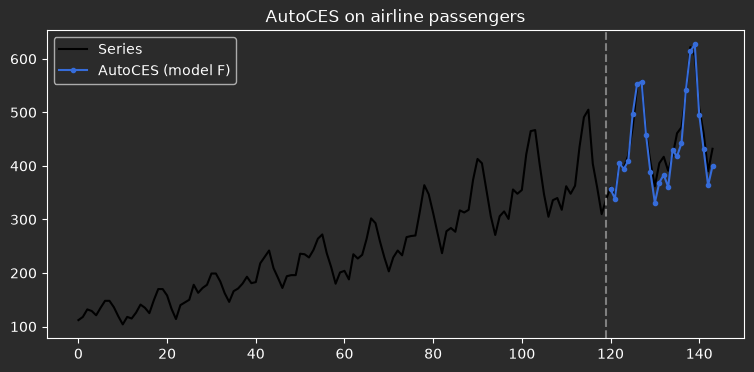

In [8]:
time = np.arange(len(y_air))
plt.figure(figsize=(9, 4))
plt.plot(time, y_air, label="Series", color="black")
plt.axvline(x=len(y_train) - 1, linestyle="--", color="grey")
fut = np.arange(len(y_train), len(y_air))
plt.plot(fut, auto_preds, marker=".", label=f"AutoCES (model {auto.best_model_name_})")
plt.legend()
plt.title("AutoCES on airline passengers")
plt.show()


- The seasonal models dramatically outperform the non-seasonal one (the `"N"` MSE is enormous by comparison), confirming you must match the seasonal structure of the data.
- `AutoCES` minimises an **information criterion** (AICc) on the training data, which
 balances fit against the number of parameters. IC selection can trade test
 accuracy for robustness against overfitting, which is usually the right default but is worth being aware of.


## 6. Summary

- **CES** generalises exponential smoothing using a **complex** smoothing parameter $\tilde{\alpha} = \alpha_0 + i\,\alpha_1$ and a two-component state.
- The non-seasonal model needs no trend/damping choice: its multi-step forecast is a $2\times2$ complex linear map, and the **eigenvalue modulus** (estimated from the data) decides whether the forecast is flat, trended, or decaying.
- Four variants (`"N"`, `"S"`, `"P"`, `"F"`) cover non-seasonal through fully-seasonal data; **`AutoCES`** selects among them by information criterion.
- Estimation matches StatsForecast's AutoCES (deterministic seeds, backfitting, same optimiser bounds), so fitted parameters transfer between the libraries.

### Reference

Svetunkov, I., & Kourentzes, N. (2018). Complex exponential smoothing for time series forecasting. *Naval Research Logistics*, 65(8), 685-704.
